# Customer Churn — Gradient Boosting (XGBoost optional)

This notebook runs fully offline.
- Generates churn-like tabular data with class imbalance
- Uses a robust preprocessing pipeline
- Tries XGBoost if installed, otherwise falls back to sklearn HistGradientBoosting
- Evaluates with ROC-AUC, PR-AUC, confusion matrix

Last rebuild: **2026-02-16 01:11:34**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, classification_report

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)


In [2]:
# 1) Synthetic churn dataset
N = 6000

tenure = np.clip(np.random.gamma(2.0, 10.0, N), 0, 120)
monthly_charges = np.clip(np.random.normal(65, 25, N), 10, 170)
contract = np.random.choice(['month-to-month', 'one-year', 'two-year'], size=N, p=[0.6, 0.25, 0.15])
pay_method = np.random.choice(['card', 'bank', 'paypal'], size=N, p=[0.4, 0.35, 0.25])

# churn probability increases with low tenure + high charges + month-to-month
logit = (
    -1.5
    + 0.02 * (monthly_charges - 60)
    - 0.03 * (tenure - 20)
    + 0.8 * (contract == 'month-to-month').astype(float)
)
p = 1 / (1 + np.exp(-logit))
y = (np.random.rand(N) < p).astype(int)

df = pd.DataFrame({
    'tenure': tenure,
    'monthly_charges': monthly_charges,
    'contract': contract,
    'pay_method': pay_method,
})

df['churn'] = y
df['churn'].mean()

0.31033333333333335

In [3]:
X = df.drop(columns=['churn'])
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

num_cols = ['tenure', 'monthly_charges']
cat_cols = ['contract', 'pay_method']

pre = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])


In [4]:
# 2) Model: try XGBoost else fallback
model_name = None
try:
    import xgboost as xgb
    clf = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
    )
    model_name = 'xgboost.XGBClassifier'
except Exception:
    from sklearn.ensemble import HistGradientBoostingClassifier
    clf = HistGradientBoostingClassifier(max_depth=4, learning_rate=0.08, max_iter=300, random_state=42)
    model_name = 'sklearn.HistGradientBoostingClassifier'

pipe = Pipeline([('pre', pre), ('clf', clf)])
pipe

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['tenure',
                                                   'monthly_charges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['contract',
                                                   'pay_method'])])),
                ('clf',
                 HistGradientBoostingClassifier(learning_rate=0.08, max_depth=4,
                                                max_iter=300,
                                                random_state=42))])

In [5]:
pipe.fit(X_train, y_train)

proba = pipe.predict_proba(X_test)[:,1] if hasattr(pipe.named_steps['clf'], 'predict_proba') else pipe.decision_function(X_test)
pred = (proba >= 0.5).astype(int)

roc = roc_auc_score(y_test, proba)
prauc = average_precision_score(y_test, proba)
print('model:', model_name)
print('ROC-AUC:', round(roc, 4))
print('PR-AUC:', round(prauc, 4))
print(classification_report(y_test, pred))

model: sklearn.HistGradientBoostingClassifier
ROC-AUC: 0.6663
PR-AUC: 0.4513
              precision    recall  f1-score   support

           0       0.73      0.87      0.79       828
           1       0.49      0.27      0.35       372

    accuracy                           0.69      1200
   macro avg       0.61      0.57      0.57      1200
weighted avg       0.66      0.69      0.66      1200



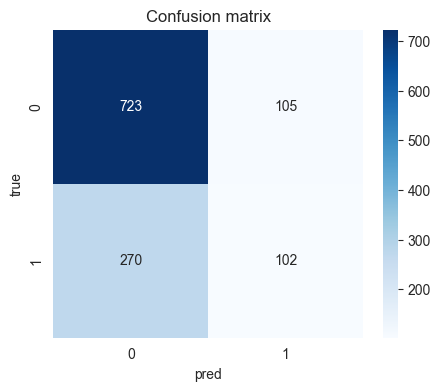

In [6]:
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion matrix')
plt.xlabel('pred')
plt.ylabel('true')
plt.show()

In [7]:
print('DONE — executed at 2026-02-16 01:11:34')

DONE — executed at 2026-02-16 01:11:34
